## Imports
Libraries for data manipulation, preprocessing, clustering and statistics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, unicodedata
from scipy import stats

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

## Data loading and cleaning
Loads the mobility dataset, harmonizes country names, and normalizes the *Fewer Opportunities* column into Yes/No/Unknown.

In [2]:
mob = pd.read_csv("df_mobility_hicp.csv").drop(columns=["Unnamed: 0"])

country_clean = {
    "Czech Republic": "Czechia",
    "Turkey": "Türkiye",
    "The Republic of North Macedonia": "North Macedonia",
}
mob["Sending Country"] = mob["Sending Country"].replace(country_clean)
mob["Receiving Country"] = mob["Receiving Country"].replace(country_clean)

def clean_fewer_opportunities(v):
    v = str(v).strip().lower()
    return {"yes": "Yes", "1": "Yes", "no": "No", "0": "No"}.get(v, "Unknown")

mob["Fewer_Opportunities_clean"] = mob["Fewer Opportunities"].apply(clean_fewer_opportunities)

## Feature engineering — field of study
Maps raw *Field of Education* values onto the 10 ISCED-F macro-fields, to avoid an overly sparse one-hot encoding.

TODO: redo the mapping once the full database is available

In [3]:
FIELD_MAP = {
    'Education':'Education','Education science':'Education',
    'Teacher training with subject specialization':'Education',
    'Teacher training without subject specialization':'Education',
    'Training for pre-school teachers':'Education',
    'Arts':'Arts and humanities','Arts and humanities':'Arts and humanities',
    'Audio-visual techniques and media production':'Arts and humanities',
    'Fine arts':'Arts and humanities','History and archaeology':'Arts and humanities',
    'Humanities (except languages)':'Arts and humanities','Language acquisition':'Arts and humanities',
    'Languages':'Arts and humanities','Literature and linguistics':'Arts and humanities',
    'Music and performing arts':'Arts and humanities','Philosophy and ethics':'Arts and humanities',
    'Religion and theology':'Arts and humanities','Fashion, interior and industrial design':'Arts and humanities',
    'Journalism and information':'Social sciences, journalism and information',
    'Journalism and reporting':'Social sciences, journalism and information',
    'Political sciences and civics':'Social sciences, journalism and information',
    'Psychology':'Social sciences, journalism and information',
    'Social and behavioural sciences':'Social sciences, journalism and information',
    'Social sciences, journalism and information':'Social sciences, journalism and information',
    'Sociology and cultural studies':'Social sciences, journalism and information',
    'Accounting and taxation':'Business, administration and law','Business and administration':'Business, administration and law',
    'Business, administration and law':'Business, administration and law','Economics':'Business, administration and law',
    'Finance, banking and insurance':'Business, administration and law','Law':'Business, administration and law',
    'Management and administration':'Business, administration and law','Marketing and advertising':'Business, administration and law',
    'Secretarial and office work':'Business, administration and law','Work skills':'Business, administration and law',
    'Biochemistry':'Natural sciences, mathematics and statistics','Biological and related sciences':'Natural sciences, mathematics and statistics',
    'Biology':'Natural sciences, mathematics and statistics','Chemistry':'Natural sciences, mathematics and statistics',
    'Earth sciences':'Natural sciences, mathematics and statistics','Environment':'Natural sciences, mathematics and statistics',
    'Environmental sciences':'Natural sciences, mathematics and statistics','Mathematics':'Natural sciences, mathematics and statistics',
    'Mathematics and statistics':'Natural sciences, mathematics and statistics','Physical sciences':'Natural sciences, mathematics and statistics',
    'Physics':'Natural sciences, mathematics and statistics','Statistics':'Natural sciences, mathematics and statistics',
    'Computer use':'Information and Communication Technologies (ICTs)',
    'Information and Communication Technologies (ICTs)':'Information and Communication Technologies (ICTs)',
    'Software and applications development and analysis':'Information and Communication Technologies (ICTs)',
    'Architecture and construction':'Engineering, manufacturing and construction',
    'Architecture and town planning':'Engineering, manufacturing and construction',
    'Building and civil engineering':'Engineering, manufacturing and construction',
    'Chemical engineering and processes':'Engineering, manufacturing and construction',
    'Electricity and energy':'Engineering, manufacturing and construction',
    'Electronics and automation':'Engineering, manufacturing and construction',
    'Engineering and engineering trades':'Engineering, manufacturing and construction',
    'Engineering, manufacturing and construction':'Engineering, manufacturing and construction',
    'Environmental protection technology':'Engineering, manufacturing and construction',
    'Food processing':'Engineering, manufacturing and construction',
    'Manufacturing and processing':'Engineering, manufacturing and construction',
    'Mechanics and metal trades':'Engineering, manufacturing and construction',
    'Mining and extraction':'Engineering, manufacturing and construction',
    'Motor vehicles, ships and aircraft':'Engineering, manufacturing and construction',
    'Textiles (clothes, footwear and leather)':'Engineering, manufacturing and construction',
    'Agriculture':'Agriculture, forestry, fisheries and veterinary',
    'Agriculture, forestry, fisheries and veterinary':'Agriculture, forestry, fisheries and veterinary',
    'Crop and livestock production':'Agriculture, forestry, fisheries and veterinary',
    'Forestry':'Agriculture, forestry, fisheries and veterinary','Veterinary':'Agriculture, forestry, fisheries and veterinary',
    'Dental studies':'Health and welfare','Health':'Health and welfare',
    'Medical diagnostic and treatment technology':'Health and welfare','Medicine':'Health and welfare',
    'Nursing and midwifery':'Health and welfare','Pharmacy':'Health and welfare',
    'Therapy and rehabilitation':'Health and welfare','Welfare':'Health and welfare',
    'Social work and counselling':'Health and welfare','Child care and youth services':'Health and welfare',
    'Domestic services':'Services','Hotel, restaurants and catering':'Services',
    'Military and defence':'Services','Personal services':'Services','Security services':'Services',
    'Services':'Services','Sports':'Services','Transport services':'Services',
    'Travel, tourism and leisure':'Services','Wholesale and retail sales':'Services',
}
mob["Field_Group"] = mob["Field of Education"].map(FIELD_MAP)

## Feature engineering — regions
Groups countries into European macro-regions (North/South/West/East + rest of world) instead of keeping them as individual categories.

In [4]:
REGION = {
 'Denmark':'Northern Europe','Estonia':'Northern Europe','Finland':'Northern Europe','Iceland':'Northern Europe',
 'Ireland':'Northern Europe','Latvia':'Northern Europe','Lithuania':'Northern Europe','Norway':'Northern Europe',
 'Sweden':'Northern Europe','United Kingdom':'Northern Europe',
 'Croatia':'Southern Europe','Cyprus':'Southern Europe','Greece':'Southern Europe','Italy':'Southern Europe',
 'Malta':'Southern Europe','Portugal':'Southern Europe','Slovenia':'Southern Europe','Spain':'Southern Europe',
 'Türkiye':'Southern Europe','Serbia':'Southern Europe','North Macedonia':'Southern Europe',
 'Austria':'Western Europe','Belgium':'Western Europe','France':'Western Europe','Germany':'Western Europe',
 'Luxembourg':'Western Europe','Netherlands':'Western Europe','Switzerland':'Western Europe',
 'Bulgaria':'Eastern Europe','Czechia':'Eastern Europe','Hungary':'Eastern Europe','Poland':'Eastern Europe',
 'Romania':'Eastern Europe','Slovakia':'Eastern Europe','Ukraine':'Eastern Europe','Azerbaijan':'Eastern Europe',
 'Algeria':'Rest of World','Argentina':'Rest of World','Japan':'Rest of World','Lebanon':'Rest of World',
 'Mexico':'Rest of World','Morocco':'Rest of World','Nepal':'Rest of World','Palestine':'Rest of World',
 'South Korea':'Rest of World','United States of America':'Rest of World'
}
mob["Sending_Region"] = mob["Sending Country"].map(REGION)
mob["Receiving_Region"] = mob["Receiving Country"].map(REGION)

## Feature engineering — HICP and country frequency
Winsorizes the HICP index (to limit the effect of Türkiye-related outliers), computes the sending/receiving differential, and the frequency of each country in the sample.

In [5]:
for col in ["Sending Country HICP", "Receiving Country HICP"]:
    lo, hi = mob[col].quantile([0.01, 0.99])
    mob[col + "_w"] = mob[col].clip(lo, hi)

mob["HICP_diff_w"] = mob["Receiving Country HICP_w"] - mob["Sending Country HICP_w"]

mob["Sending_Country_Freq"] = mob["Sending Country"].map(mob["Sending Country"].value_counts(normalize=True))
mob["Receiving_Country_Freq"] = mob["Receiving Country"].map(mob["Receiving Country"].value_counts(normalize=True))

## Column blocks for clustering
Splits features into three semantic groups — demographic, geo-economic, field of study — so they can be weighted independently.

In [6]:
demo_num_cols = ["Mobility Duration", "Participant Age"]
demo_cat_cols = ["Participant Gender", "Fewer_Opportunities_clean", "Education Level"]
geo_num_cols  = ["Sending Country HICP_w", "Receiving Country HICP_w", "HICP_diff_w",
                  "Sending_Country_Freq", "Receiving_Country_Freq"]
geo_cat_cols  = ["Sending_Region", "Receiving_Region"]
field_cat_cols = ["Field_Group"]

num_cols_all = demo_num_cols + geo_num_cols
mob[num_cols_all] = mob[num_cols_all].fillna(mob[num_cols_all].median())
print(mob[num_cols_all].isna().sum())

Mobility Duration           0
Participant Age             0
Sending Country HICP_w      0
Receiving Country HICP_w    0
HICP_diff_w                 0
Sending_Country_Freq        0
Receiving_Country_Freq      0
dtype: int64


## Weighted preprocessing pipeline
Defines a function that builds the feature matrix by scaling/one-hot-encoding each block with a configurable weight, and four weight combinations to compare: baseline, geo-economic emphasis, demographic/field emphasis, and an **equity/didactic focus** that removes the geographic blocks entirely (weight 0) to check whether a socio-didactic pattern exists independently of geography.

In [7]:
def build_matrix(weights):
    ct = ColumnTransformer([
        ("demo_num", StandardScaler(), demo_num_cols),
        ("demo_cat", OneHotEncoder(handle_unknown="ignore"), demo_cat_cols),
        ("geo_num", StandardScaler(), geo_num_cols),
        ("geo_cat", OneHotEncoder(handle_unknown="ignore"), geo_cat_cols),
        ("field_cat", OneHotEncoder(handle_unknown="ignore"), field_cat_cols),
    ], transformer_weights=weights)
    Xt = ct.fit_transform(mob)
    return Xt.toarray() if hasattr(Xt, "toarray") else Xt

versions = {
    "baseline": {"demo_num": 1, "demo_cat": 1, "geo_num": 1, "geo_cat": 1, "field_cat": 1},
    "geo_economic_focus": {"demo_num": 0.5, "demo_cat": 0.5, "geo_num": 2, "geo_cat": 2, "field_cat": 1},
    "demo_field_focus": {"demo_num": 2, "demo_cat": 2, "geo_num": 0.5, "geo_cat": 0.5, "field_cat": 2},
    "equity_focus": {"demo_num": 1, "demo_cat": 1, "geo_num": 0, "geo_cat": 0, "field_cat": 1},
}

## Elbow and silhouette per version
For each weighted version, scans k=2..10 with elbow and silhouette, automatically picks the best k (excluding k=2, which only isolates outliers) and trains the final KMeans.

c:\Users\User\anaconda3\envs\geo\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


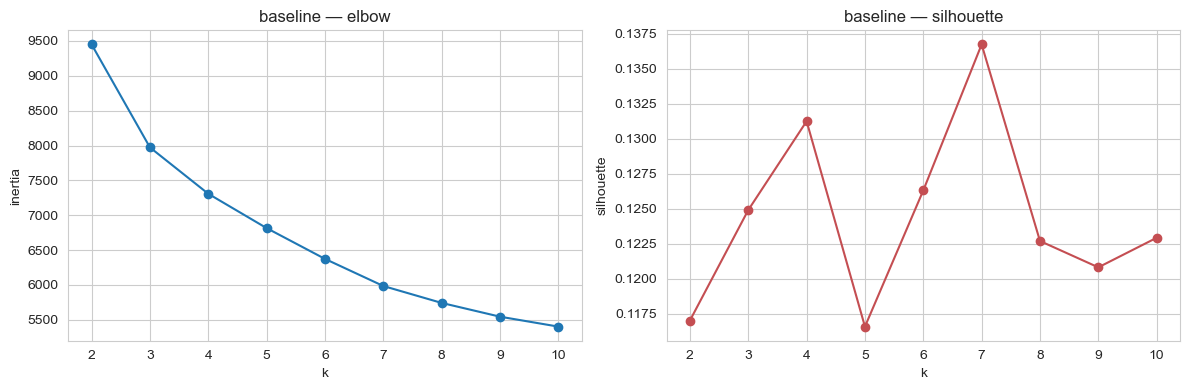

baseline: best_k=7, silhouette=0.137


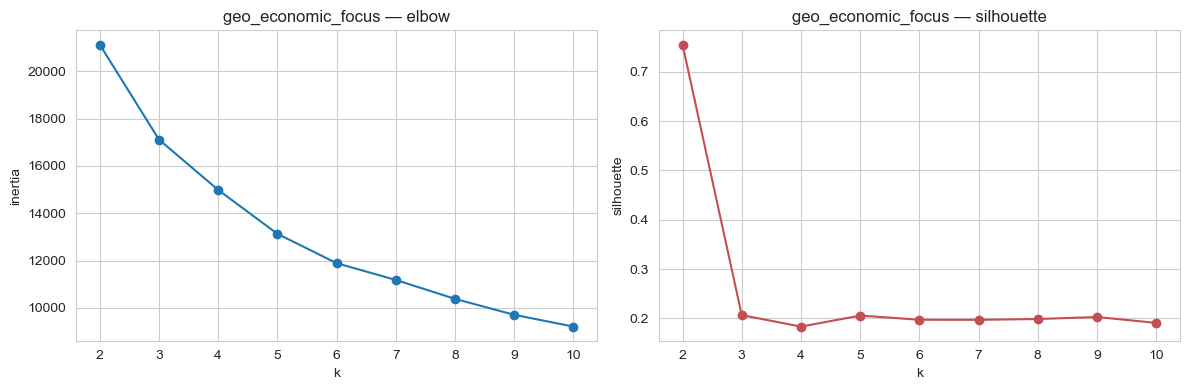

geo_economic_focus: best_k=3, silhouette=0.207


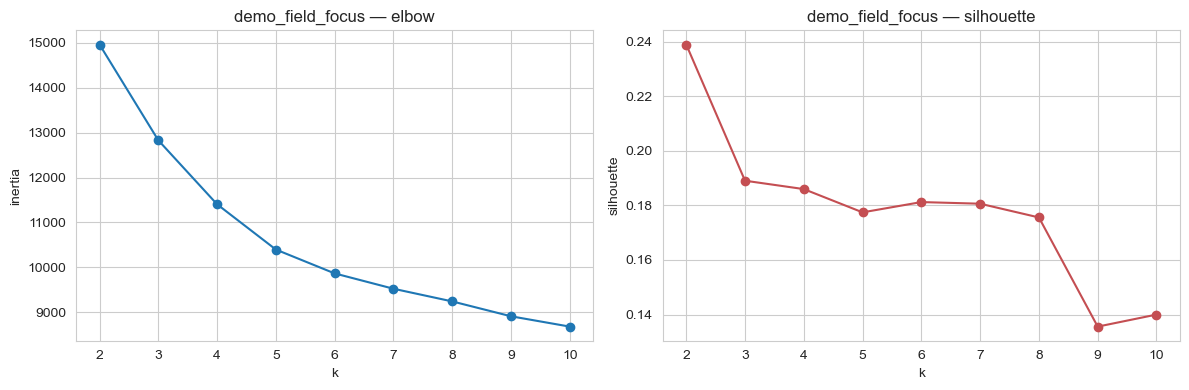

demo_field_focus: best_k=3, silhouette=0.189


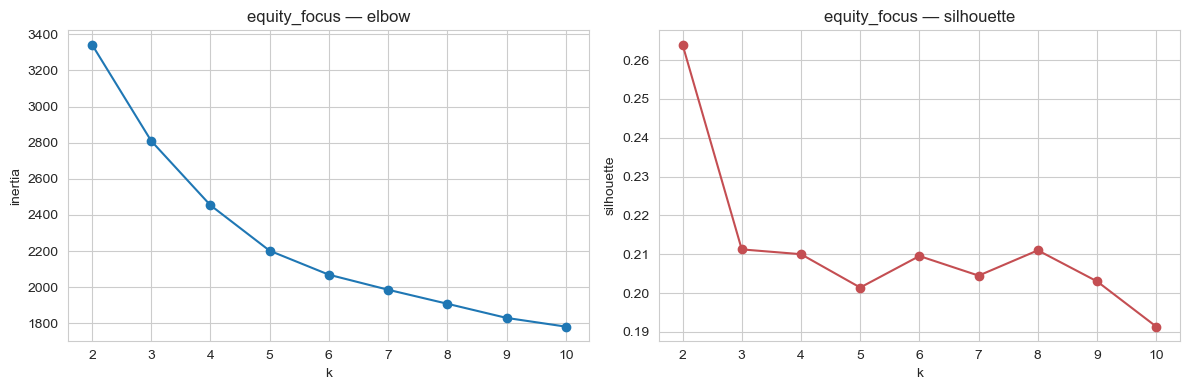

equity_focus: best_k=3, silhouette=0.211


In [8]:
results = {}

for name, w in versions.items():
    Xt = build_matrix(w)
    inertias, sils = [], []
    k_range = range(2, 11)
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(Xt)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(Xt, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(list(k_range), inertias, marker="o")
    axes[0].set_title(f"{name} — elbow")
    axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
    axes[1].plot(list(k_range), sils, marker="o", color="#C44E52")
    axes[1].set_title(f"{name} — silhouette")
    axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette")
    plt.tight_layout()
    plt.show()

    best_k = list(k_range)[int(np.argmax(sils[1:])) + 1]
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels_final = km_final.fit_predict(Xt)
    sil_final = silhouette_score(Xt, labels_final)

    results[name] = {"X": Xt, "k": best_k, "labels": labels_final, "silhouette": sil_final}
    print(f"{name}: best_k={best_k}, silhouette={sil_final:.3f}")

## PCA projection per version
Projects each version onto 2 principal components to visually inspect how well-separated the resulting clusters are.

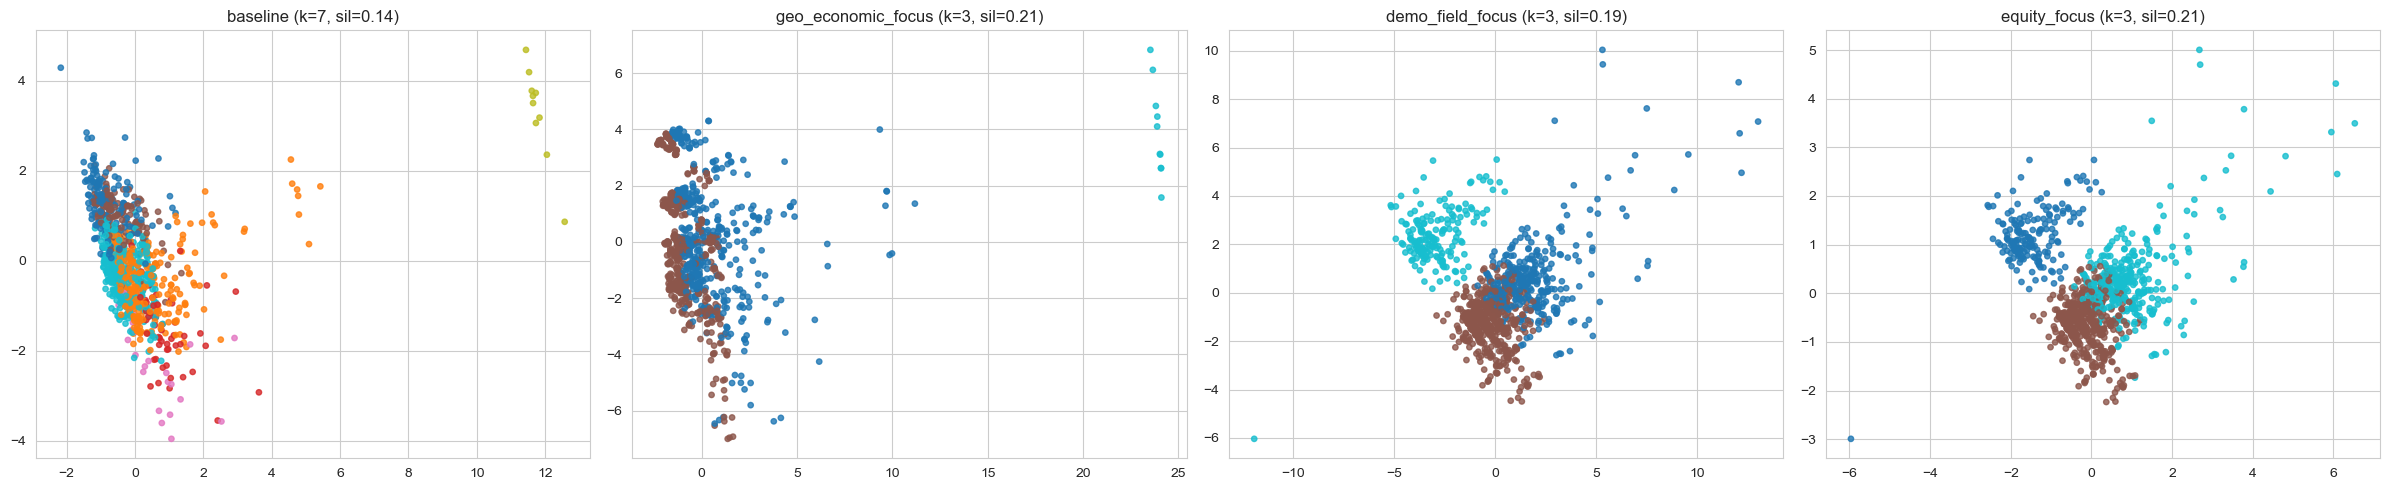

In [9]:
fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 5))
for ax, (name, r) in zip(axes, results.items()):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(r["X"])
    k_r, sil_r = r["k"], r["silhouette"]
    ax.scatter(coords[:, 0], coords[:, 1], c=r["labels"], cmap="tab10", s=15, alpha=0.8)
    ax.set_title(f"{name} (k={k_r}, sil={sil_r:.2f})")
plt.tight_layout()
plt.show()

## Silhouette comparison across versions
Summary table comparing the chosen k and silhouette score across the four versions, to see which feature grouping discriminates best.

In [10]:
summary = pd.DataFrame({
    "version": list(results.keys()),
    "best_k": [r["k"] for r in results.values()],
    "silhouette": [round(r["silhouette"], 3) for r in results.values()],
}).sort_values("silhouette", ascending=False)
summary

,version,best_k,silhouette
3,equity_focus,3,0.211
1,geo_economic_focus,3,0.207
2,demo_field_focus,3,0.189
0,baseline,7,0.137


## Best version selection
Picks the version with the highest silhouette score and assigns the corresponding cluster labels to the main dataframe.

In [11]:
best_version = summary.iloc[0]["version"]
mob["cluster"] = results[best_version]["labels"]
best_version

'equity_focus'

## Per-sample silhouette plot
Shows the distribution of silhouette coefficients per individual sample, grouped by cluster, for the chosen version.

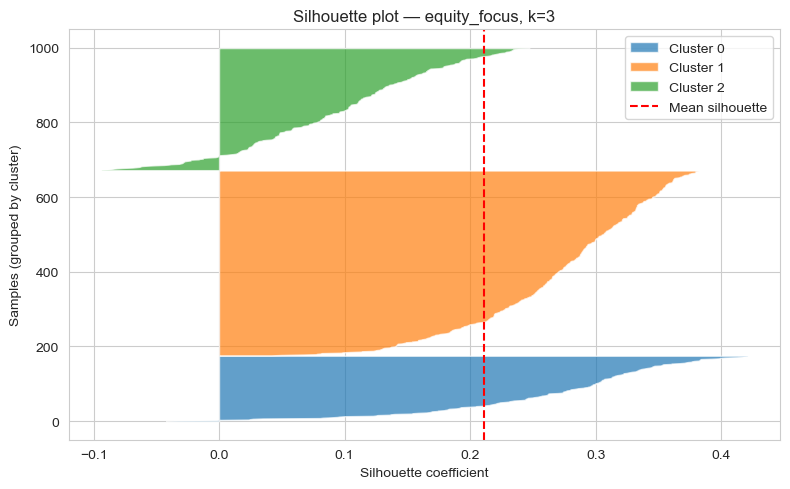

In [12]:
sil_vals = silhouette_samples(results[best_version]["X"], mob["cluster"])
best_k_final = results[best_version]["k"]
fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 0
for i in sorted(mob["cluster"].unique()):
    vals = np.sort(sil_vals[mob["cluster"] == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, label=f"Cluster {i}")
    y_lower = y_upper
ax.axvline(sil_vals.mean(), color="red", linestyle="--", label="Mean silhouette")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Samples (grouped by cluster)")
ax.set_title(f"Silhouette plot — {best_version}, k={best_k_final}")
ax.legend()
plt.tight_layout()
plt.show()

## Cluster profiling — numeric features
Mean of each numeric feature by cluster.

In [13]:
numeric_profile = mob.groupby("cluster")[num_cols_all].mean().round(2)
numeric_profile

,Mobility Duration,Participant Age,Sending Country HICP_w,Receiving Country HICP_w,HICP_diff_w,Sending_Country_Freq,Receiving_Country_Freq
cluster,,,,,,,
0,276.07,21.30,107.33,107.27,-0.59,0.09,0.07
1,117.08,21.23,116.08,109.80,-5.73,0.08,0.07
2,121.74,25.22,112.66,110.55,-2.06,0.08,0.06


## Cluster profiling — categorical features
Distribution (row-normalized) of each categorical feature by cluster.

In [14]:
for col in demo_cat_cols + geo_cat_cols + field_cat_cols:
    print(f"\n--- {col} ---")
    print(pd.crosstab(mob["cluster"], mob[col], normalize="index").round(2))


--- Participant Gender ---
Participant Gender  Female  Male
cluster                         
0                     0.62  0.38
1                     0.63  0.37
2                     0.62  0.38

--- Fewer_Opportunities_clean ---
Fewer_Opportunities_clean    No  Unknown   Yes
cluster                                       
0                          0.76     0.07  0.16
1                          0.85     0.06  0.09
2                          0.84     0.07  0.09

--- Education Level ---
Education Level  ISCED-5 - Short cycle within the first cycle / Short-cycle tertiary education (EQF-5)  \
cluster                                                                                                  
0                                                             0.00                                       
1                                                             0.02                                       
2                                                             0.00                      

## Standardized profile heatmap
Z-score of each cluster's mean relative to the overall mean, for numeric features.

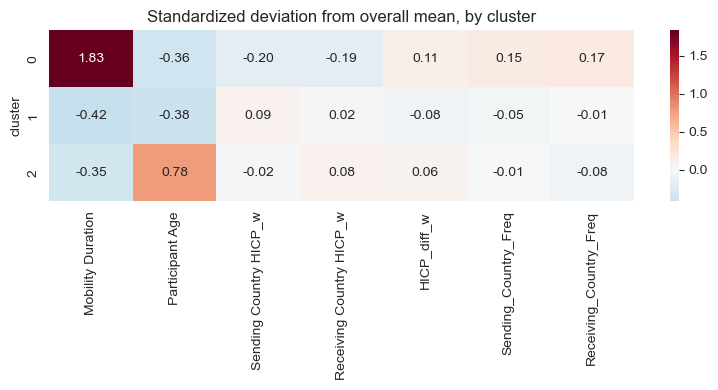

In [15]:
z_profile = (mob.groupby("cluster")[num_cols_all].mean() - mob[num_cols_all].mean()) / mob[num_cols_all].std()

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(z_profile, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Standardized deviation from overall mean, by cluster")
plt.tight_layout()
plt.show()

## Statistical tests across clusters
One-way ANOVA for numeric features, chi-square for categorical features.

In [16]:
from scipy.stats import f_oneway

anova_rows = []
for col in num_cols_all:
    groups = [g[col].values for _, g in mob.groupby("cluster")]
    f_stat, p = f_oneway(*groups)
    anova_rows.append({"feature": col, "F": round(f_stat, 2), "p_value": round(p, 4)})
pd.DataFrame(anova_rows)

,feature,F,p_value
0,Mobility Duration,1278.86,0.0000
1,Participant Age,207.49,0.0000
2,Sending Country HICP_w,5.44,0.0045
3,Receiving Country HICP_w,4.47,0.0117
4,HICP_diff_w,3.31,0.0370
5,Sending_Country_Freq,2.75,0.0642
6,Receiving_Country_Freq,3.59,0.0278


In [17]:
chi2_rows = []
for col in demo_cat_cols + geo_cat_cols + field_cat_cols:
    chi2, p, dof, expected = stats.chi2_contingency(pd.crosstab(mob["cluster"], mob[col]))
    chi2_rows.append({"feature": col, "chi2": round(chi2, 2), "dof": dof, "p_value": round(p, 4)})
pd.DataFrame(chi2_rows)

,feature,chi2,dof,p_value
0,Participant Gender,0.11,2,0.9473
1,Fewer_Opportunities_clean,9.12,4,0.0582
2,Education Level,700.14,10,0.0000
3,Sending_Region,51.45,8,0.0000
4,Receiving_Region,16.95,8,0.0307
5,Field_Group,52.17,18,0.0000


## Within-cluster consistency
Per-sample silhouette values, with the lowest-silhouette (most ambiguous) samples per cluster.

In [18]:
mob["silhouette"] = sil_vals
mob.sort_values("silhouette").groupby("cluster").head(5)

,Academic Year,Mobility Duration,Field of Education,Participant Country,Education Level,Participant Gender,Fewer Opportunities,Participant Age,Sending Country,Sending Country HICP,Sending City,Sending Organization,Receiving Country,Receiving Country HICP,Receiving City,Receiving Organization,Fewer_Opportunities_clean,Field_Group,Sending_Region,Receiving_Region,Sending Country HICP_w,Receiving Country HICP_w,HICP_diff_w,Sending_Country_Freq,Receiving_Country_Freq,cluster,silhouette
831,2014,122,Business and administration,Germany,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,No,26,Germany,99.30,OSNABRUCK,STIFTUNG FACHHOCHSCHULE OSNABRUECK,Italy,99.90,TORINO,UNIVERSITA DEGLI STUDI DI TORINO,No,"Business, administration and law",Western Europe,Southern Europe,99.30,99.90,0.60,0.147,0.089,2,-0.094034
509,2018,80,Marketing and advertising,Spain,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,No,26,Spain,103.46,CADIZ,UNIVERSIDAD DE CADIZ,United Kingdom,105.90,LONDRES,VIRTUAL HUMAN RESOURCES LTD,No,"Business, administration and law",Southern Europe,Northern Europe,103.46,105.90,2.44,0.120,0.067,2,-0.093490
467,2019,121,"Fashion, interior and industrial design",Cyprus,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,No,26,United Kingdom,107.80,BRISTOL,"UNIVERSITY OF THE WEST OF ENGLAND, BRISTOL",Netherlands,105.78,Amsterdam,Iris van Herpen BV,No,Arts and humanities,Northern Europe,Western Europe,107.80,105.78,-2.02,0.054,0.039,2,-0.086916
626,2018,133,Languages,Germany,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,No,26,Germany,104.00,Hamburg,UNIVERSITAET HAMBURG,Spain,103.46,Sevilla,UNIVERSIDAD PABLO DE OLAVIDE,No,Arts and humanities,Western Europe,Southern Europe,104.00,103.46,-0.54,0.147,0.144,2,-0.085304
495,2020,88,Transport services,Latvia,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,No,26,Latvia,108.62,Riga,SIA NOVIKONTAS JURAS KOLEDZA,Denmark,102.90,Copenhagen,Monjasa,No,Services,Northern Europe,Northern Europe,108.62,102.90,-5.72,0.006,0.024,2,-0.084325
854,2019,198,Audio-visual techniques and media production,Germany,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,No,21,Germany,105.50,Köln,UNIVERSITAET ZU KÖLN,Italy,103.20,Bologna,ALMA MATER STUDIORUM - UNIVERSITA DI BOLOGNA,No,Arts and humanities,Western Europe,Southern Europe,105.50,103.20,-2.30,0.147,0.089,0,-0.042098
175,2017,200,"Engineering, manufacturing and construction",Germany,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,No,22,Germany,102.10,Dresden,TECHNISCHE UNIVERSITAET DRESDEN,United Kingdom,103.40,Oxford,BMW (UK) Manufacturing Ltd. Plant Oxford,No,"Engineering, manufacturing and construction",Western Europe,Northern Europe,102.10,103.40,1.30,0.147,0.067,0,-0.032897
157,2016,201,"Fashion, interior and industrial design",Turkey,ISCED-5 - Short-cycle within the first cycle /...,Female,No,21,Türkiye,107.66,ISTANBUL,ISTANBUL SISLI MESLEK YUKSEKOKULU,Italy,99.90,Naples,Accademia della Moda,No,Arts and humanities,Southern Europe,Southern Europe,107.66,99.90,-7.76,0.057,0.089,0,-0.001883
442,2019,208,"Travel, tourism and leisure",Germany,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,No,22,Netherlands,105.78,LEEUWARDEN,Stichting NHL Stenden Hogeschool,Germany,105.50,Hamburg,Hamburg Tourismus GmbH,No,Services,Western Europe,Western Europe,105.78,105.50,-0.28,0.053,0.096,0,-0.000585
451,2021,210,Physics,Spain,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,0,21,Spain,107.04,OVIEDO,UNIOVI,Portugal,104.55,PORTO,UPORTO,No,"Natural sciences, mathematics and statistics",Southern Europe,Southern Europe,107.04,104.55,-2.49,0.120,0.053,0,0.023395


## Region-stratified clustering — isolating geography
Instead of removing the geographic block via weights, this clusters demographic + field features **separately within each sending region**, so geography cannot influence cluster assignment at all. For each region, k is scanned over a small range and picked by silhouette; results are stored in `mob['cluster_within_region']` (not comparable across regions, since cluster 0 in one region is unrelated to cluster 0 in another).

In [19]:
within_region_cols_num = demo_num_cols
within_region_cols_cat = demo_cat_cols + field_cat_cols

mob["cluster_within_region"] = -1
region_results = {}

for region in mob["Sending_Region"].dropna().unique():
    sub = mob[mob["Sending_Region"] == region]
    if len(sub) < 20:
        continue

    ct = ColumnTransformer([
        ("num", StandardScaler(), within_region_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), within_region_cols_cat),
    ])
    Xt = ct.fit_transform(sub)
    Xt = Xt.toarray() if hasattr(Xt, "toarray") else Xt

    k_range = range(2, min(6, len(sub) // 10 + 2))
    sils = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(Xt)
        sils.append(silhouette_score(Xt, labels))

    best_k = list(k_range)[int(np.argmax(sils))]
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels_final = km_final.fit_predict(Xt)
    sil_final = silhouette_score(Xt, labels_final)

    mob.loc[sub.index, "cluster_within_region"] = labels_final
    region_results[region] = {"k": best_k, "silhouette": round(sil_final, 3), "n": len(sub)}

pd.DataFrame(region_results).T

c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\User\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

,k,silhouette,n
Western Europe,2.0,0.290,394.0
Northern Europe,3.0,0.266,137.0
Eastern Europe,4.0,0.205,114.0
Southern Europe,2.0,0.258,350.0


### Region-stratified cluster profiles
For each region, the categorical/numeric composition of its internal clusters — this is where a socio-didactic pattern (independent of geography) would show up, if one exists.

In [20]:
for region in region_results:
    sub = mob[mob["Sending_Region"] == region]
    print(f"\n=== {region} (k={region_results[region]['k']}, silhouette={region_results[region]['silhouette']}) ===")
    print(sub.groupby("cluster_within_region")[within_region_cols_num].mean().round(2))
    print(sub.groupby("cluster_within_region")["Field_Group"].agg(lambda s: s.value_counts(normalize=True).idxmax()))


=== Western Europe (k=2, silhouette=0.29) ===
                       Mobility Duration  Participant Age
cluster_within_region                                    
0                                 118.33            22.41
1                                 270.38            21.15
cluster_within_region
0    Business, administration and law
1                 Arts and humanities
Name: Field_Group, dtype: object

=== Northern Europe (k=3, silhouette=0.266) ===
                       Mobility Duration  Participant Age
cluster_within_region                                    
0                                 112.67            22.89
1                                 276.61            20.78
2                                 142.67            42.83
cluster_within_region
0    Arts and humanities
1    Arts and humanities
2    Arts and humanities
Name: Field_Group, dtype: object

=== Eastern Europe (k=4, silhouette=0.205) ===
                       Mobility Duration  Participant Age
cluster_within_

## K-Prototypes clustering
KMeans on one-hot-encoded categoricals treats every category pair as equally different and lets high-cardinality categoricals dominate distance purely through dimensionality. K-Prototypes avoids this: it computes Euclidean distance on numeric features and simple mismatch (Hamming) dissimilarity on categoricals directly, weighted by `gamma`, without one-hot encoding at all. Run on the full unweighted feature set (demo + geo + field) for a fair comparison with the KMeans baseline.

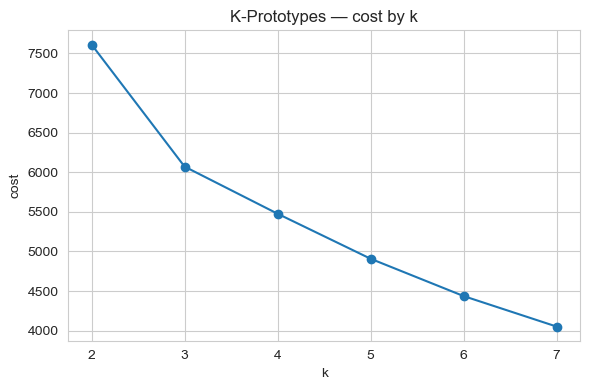

In [21]:
from kmodes.kprototypes import KPrototypes

kproto_num_cols = demo_num_cols + geo_num_cols
kproto_cat_cols = demo_cat_cols + geo_cat_cols + field_cat_cols
kproto_cols = kproto_num_cols + kproto_cat_cols

X_kproto = mob[kproto_cols].copy()
X_kproto[kproto_num_cols] = StandardScaler().fit_transform(X_kproto[kproto_num_cols])
X_kproto[kproto_cat_cols] = X_kproto[kproto_cat_cols].astype(str)

cat_idx = [X_kproto.columns.get_loc(c) for c in kproto_cat_cols]
X_kproto_matrix = X_kproto.to_numpy()

kproto_costs = []
k_range_proto = range(2, 8)
for k in k_range_proto:
    kp = KPrototypes(n_clusters=k, init="Cao", random_state=42, n_init=3, verbose=0)
    kp.fit_predict(X_kproto_matrix, categorical=cat_idx)
    kproto_costs.append(kp.cost_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(k_range_proto), kproto_costs, marker="o")
ax.set_title("K-Prototypes — cost by k")
ax.set_xlabel("k"); ax.set_ylabel("cost")
plt.tight_layout()
plt.show()

### K-Prototypes — final model and silhouette
Picks k from the elbow above, fits the final model, and computes silhouette on the same mixed feature space (via Gower-style distance approximation: standardized numerics + one-hot categoricals, used only for scoring, not for fitting) so it is comparable to the KMeans results.

In [22]:
best_k_proto = 3  # set from the elbow plot above

kp_final = KPrototypes(n_clusters=best_k_proto, init="Cao", random_state=42, n_init=5, verbose=0)
labels_proto = kp_final.fit_predict(X_kproto_matrix, categorical=cat_idx)

Xt_for_scoring = build_matrix(versions["baseline"])
sil_proto = silhouette_score(Xt_for_scoring, labels_proto)
mob["cluster_kproto"] = labels_proto
print(f"K-Prototypes: k={best_k_proto}, silhouette (on one-hot space, for comparison only)={sil_proto:.3f}")

K-Prototypes: k=3, silhouette (on one-hot space, for comparison only)=0.125


### K-Prototypes cluster profiling
Same profiling logic as for the KMeans clusters, applied to the K-Prototypes labels.

In [23]:
print(mob.groupby("cluster_kproto")[kproto_num_cols].mean().round(2))
for col in kproto_cat_cols:
    print(f"\n--- {col} ---")
    print(pd.crosstab(mob["cluster_kproto"], mob[col], normalize="index").round(2))

                Mobility Duration  Participant Age  Sending Country HICP_w  \
cluster_kproto                                                               
0                          106.71            23.76                  315.91   
1                          141.82            22.68                  111.81   
2                          152.14            22.39                  108.23   

                Receiving Country HICP_w  HICP_diff_w  Sending_Country_Freq  \
cluster_kproto                                                                
0                                 124.71      -175.54                  0.06   
1                                 109.31        -3.00                  0.03   
2                                 109.36         1.44                  0.13   

                Receiving_Country_Freq  
cluster_kproto                          
0                                 0.05  
1                                 0.07  
2                                 0.07  

--- Par

## FAMD + KMeans
Factor Analysis of Mixed Data reduces demo + geo + field features to a small set of components that respect the mixed numeric/categorical nature of the data (unlike plain PCA on one-hot encodings), then KMeans is run on those components instead of on the raw one-hot matrix.

In [24]:
import prince

famd_cols = demo_num_cols + demo_cat_cols + geo_num_cols + geo_cat_cols + field_cat_cols
X_famd = mob[famd_cols].copy()

# Collapse rare categories before FAMD: MCA/FAMD inertia is inflated by categories
# with very few observations, which get projected far from the rest and are then
# picked up by KMeans as spurious "clusters". Anything under 1% of the sample is
# merged into "Other" per column.
for col in demo_cat_cols + geo_cat_cols + field_cat_cols:
    X_famd[col] = X_famd[col].astype(str)
    freq = X_famd[col].value_counts(normalize=True)
    rare = freq[freq < 0.01].index
    X_famd[col] = X_famd[col].where(~X_famd[col].isin(rare), "Other")

# rescale_with_std=True is essential here: prince.FAMD only centers numeric columns
# by default and does not scale them, so unscaled HICP (up to 370 for the highest
# sending country) would otherwise dominate the whole distance space.
famd = prince.FAMD(n_components=5, random_state=42, rescale_with_std=True)
famd = famd.fit(X_famd)
famd_coords = famd.transform(X_famd)

print(famd.eigenvalues_summary)

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              3.053         1.05%                      1.05%
1              2.804         0.96%                      2.01%
2              2.604         0.90%                      2.91%
3              2.291         0.79%                      3.70%
4              2.195         0.75%                      4.45%


### FAMD component scatter
2D projection on the first two FAMD components, colored by the KMeans labels obtained on those components below.

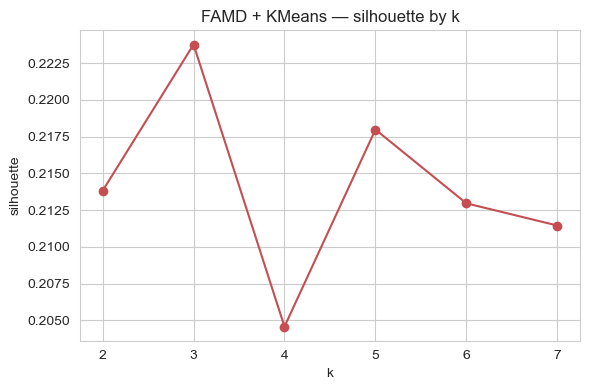

FAMD + KMeans: k=3, silhouette=0.224
2    527
1    304
0    169
Name: count, dtype: int64


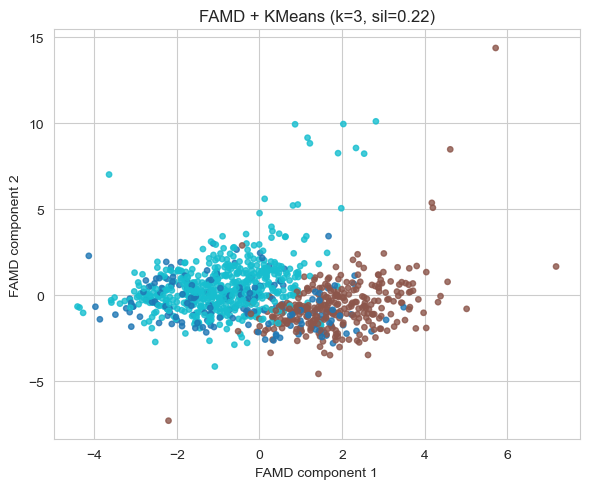

In [25]:
famd_sils = []
k_range_famd = range(2, 8)
for k in k_range_famd:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(famd_coords)
    famd_sils.append(silhouette_score(famd_coords, labels))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(k_range_famd), famd_sils, marker="o", color="#C44E52")
ax.set_title("FAMD + KMeans — silhouette by k")
ax.set_xlabel("k"); ax.set_ylabel("silhouette")
plt.tight_layout()
plt.show()

best_k_famd = list(k_range_famd)[int(np.argmax(famd_sils))]
km_famd = KMeans(n_clusters=best_k_famd, random_state=42, n_init=10)
labels_famd = km_famd.fit_predict(famd_coords)
sil_famd = silhouette_score(famd_coords, labels_famd)
mob["cluster_famd"] = labels_famd
print(f"FAMD + KMeans: k={best_k_famd}, silhouette={sil_famd:.3f}")
print(pd.Series(labels_famd).value_counts())  # sanity check: flag tiny outlier clusters inflating silhouette

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(famd_coords.iloc[:, 0], famd_coords.iloc[:, 1], c=labels_famd, cmap="tab10", s=15, alpha=0.8)
ax.set_xlabel("FAMD component 1"); ax.set_ylabel("FAMD component 2")
ax.set_title(f"FAMD + KMeans (k={best_k_famd}, sil={sil_famd:.2f})")
plt.tight_layout()
plt.show()

### Comparison across all four approaches
KMeans (best weighted version), K-Prototypes, and FAMD + KMeans, side by side on silhouette.

In [26]:
comparison = pd.DataFrame([
    {"method": f"KMeans ({best_version})", "k": results[best_version]["k"], "silhouette": round(results[best_version]["silhouette"], 3)},
    {"method": "K-Prototypes", "k": best_k_proto, "silhouette": round(sil_proto, 3)},
    {"method": "FAMD + KMeans", "k": best_k_famd, "silhouette": round(sil_famd, 3)},
]).sort_values("silhouette", ascending=False)
comparison

,method,k,silhouette
2,FAMD + KMeans,3,0.224
0,KMeans (equity_focus),3,0.211
1,K-Prototypes,3,0.125


## STEM definition
Defines which *Field_Group* values count as STEM (natural sciences, ICT, engineering) and creates the `is_stem` flag.

In [27]:
STEM_GROUPS = [
    "Natural sciences, mathematics and statistics",
    "Information and Communication Technologies (ICTs)",
    "Engineering, manufacturing and construction",
]
mob["is_stem"] = mob["Field_Group"].isin(STEM_GROUPS)

## STEM trend over time
Computes the share of STEM mobility per academic year and estimates a linear trend (slope + p-value) rather than a forecast, consistent with the small number of available years.

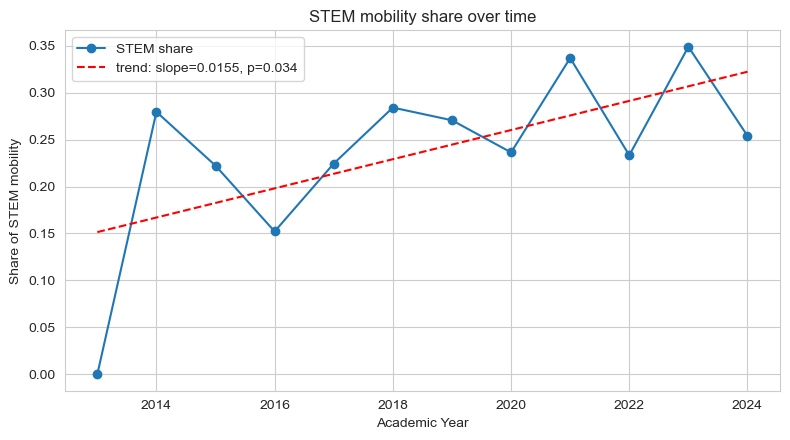

slope=0.0155  r²=0.376  p-value=0.034


In [28]:
yearly_stem = mob.groupby("Academic Year")["is_stem"].mean().sort_index()

slope, intercept, r_value, p_value, std_err = stats.linregress(yearly_stem.index, yearly_stem.values)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(yearly_stem.index, yearly_stem.values, marker="o", label="STEM share")
ax.plot(yearly_stem.index, intercept + slope * yearly_stem.index, "--", color="red",
        label=f"trend: slope={slope:.4f}, p={p_value:.3f}")
ax.set_xlabel("Academic Year")
ax.set_ylabel("Share of STEM mobility")
ax.set_title("STEM mobility share over time")
ax.legend()
plt.tight_layout()
plt.show()

print(f"slope={slope:.4f}  r²={r_value**2:.3f}  p-value={p_value:.3f}")

## Cluster association — STEM
Chi-square test to check whether the STEM share varies significantly across the identified clusters.

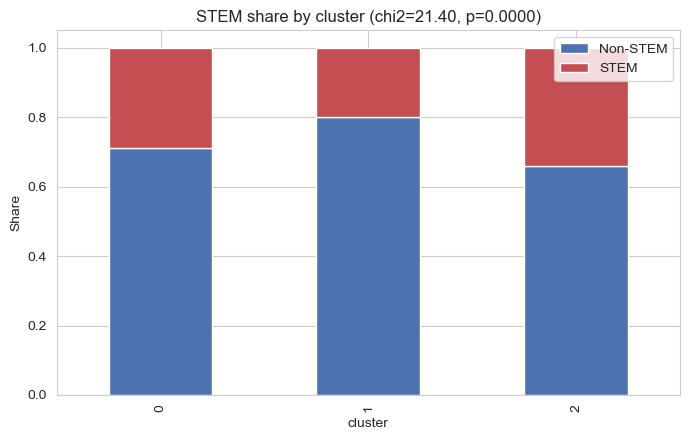

is_stem,False,True
cluster,,
0,125,51
1,397,99
2,216,112


In [29]:
ct = pd.crosstab(mob["cluster"], mob["is_stem"], normalize="index")
chi2, p, dof, expected = stats.chi2_contingency(pd.crosstab(mob["cluster"], mob["is_stem"]))

fig, ax = plt.subplots(figsize=(7, 4.5))
ct.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Share")
ax.set_title(f"STEM share by cluster (chi2={chi2:.2f}, p={p:.4f})")
ax.legend(["Non-STEM", "STEM"], title="")
plt.tight_layout()
plt.show()

pd.crosstab(mob["cluster"], mob["is_stem"])